# 05 — Structural vs. Spectral Similarity

Validates that DEPT cosine similarity is a reliable proxy for structural relatedness.

For each of three Tanimoto structural similarity bins (< 0.3, 0.3–0.6, > 0.6), we sample
1,000 compound pairs from the experimental query set and compute their DEPT cosine similarity
using two methods:

- **DEPT-Match**: Hungarian peak assignment with cosine scoring
- **Gaussian**: Gaussian vector encoding with cosine similarity

Split violin plots then show how spectral similarity tracks structural relatedness across bins.

## Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from tqdm import tqdm

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

from dept_similarity.constants import PROCESSED_DATA_DIR, BASELINE_PARAMS, RESULTS_DIR
from dept_similarity.spectral_matching import (
    align_dept_peaks_hungarian,
    cosine_from_alignment,
)
from dept_similarity.gaussian_vector import generate_gaussian_vector
from dept_similarity.match import get_metrics_at_k
from dept_similarity.score import compute_metric_numba

RANDOM_SEED = 42
N_PAIRS_PER_BIN = 1_000

# Colors from the target figure
COLOR_HUNGARIAN = "#8499a4"  # slate  — DEPT-Match
COLOR_GAUSS = "#debe8f"  # amber  — Gaussian

# Three equally spaced Tanimoto bins (thirds of [0, 1])
BIN_LABELS = ["0 – 0.33", "0.33 – 0.66", "0.66 – 1.00"]

## Load experimental query spectra

In [2]:
query_spectra_df = pd.read_parquet(
    f"{PROCESSED_DATA_DIR}/experimental_validation_set.parquet"
)
print(f"Loaded {len(query_spectra_df):,} query compounds")
query_spectra_df[["compound_id", "smiles", "inchikey14"]].head(3)

Loaded 648 query compounds


,compound_id,smiles,inchikey14
0,nmrshiftdb2_10008594,C1=Cc2ccccc2C=CC1,AATMCCVYMZDTCD
1,nmrshiftdb2_60004200,C=C/C(C)=C/C[C@H]1C(C)=CCC2C(C)(C)CCC[C@@]21C,AAWKCAAKYFTATH
2,nmrshiftdb2_60005290,CCC(C)C1(O)OC2CC3(C)OC(=CC3=O)/C(C)=C\C3OC(=O)...,ABLNQMKQYJQVRR


## Compute Morgan fingerprints (radius = 2)

Filter out any compounds whose SMILES cannot be parsed.

In [3]:
valid_rows = []
fps = []

for _, row in tqdm(
    query_spectra_df.iterrows(),
    total=len(query_spectra_df),
    desc="Computing fingerprints",
):
    mol = Chem.MolFromSmiles(row["smiles"]) if pd.notna(row["smiles"]) else None
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    fps.append(fp)
    valid_rows.append(row)

valid_df = pd.DataFrame(valid_rows).reset_index(drop=True)
print(
    f"{len(fps):,} compounds with valid fingerprints (dropped {len(query_spectra_df) - len(fps):,})"
)

Computing fingerprints:   0%|          | 0/648 [00:00<?, ?it/s]

Computing fingerprints: 100%|██████████| 648/648 [00:00<00:00, 7713.73it/s]

648 compounds with valid fingerprints (dropped 0)


## Compute all pairwise Tanimoto similarities

For ~3,600 compounds the upper triangle has ≈ 6.7 M pairs.
RDKit's `BulkTanimotoSimilarity` handles this in seconds.

Pairs are collected into three equally spaced bins (0–0.33, 0.33–0.66, 0.66–1.00).
Row order is shuffled with a fixed seed so early stopping collects pairs uniformly across
the dataset rather than biasing toward compounds with small indices.

In [4]:
n = len(fps)
rng = np.random.default_rng(RANDOM_SEED)

# Shuffle row order so early stopping samples uniformly across the dataset
row_order = rng.permutation(n)

# Storage: one list of (idx_a, idx_b, tanimoto) tuples per bin
bin_store: dict[str, list[tuple[int, int, float]]] = {label: [] for label in BIN_LABELS}


def _assign_bin(sim: float) -> str | None:
    if sim < 1 / 3:
        return "0 – 0.33"
    elif sim < 2 / 3:
        return "0.33 – 0.66"
    else:
        return "0.66 – 1.00"


pairs_computed = 0

for i in tqdm(row_order, desc="Computing Tanimoto similarities"):
    # Check early exit before each row
    if all(len(bin_store[lbl]) >= N_PAIRS_PER_BIN for lbl in BIN_LABELS):
        break

    # Only compare against compounds with a higher index to avoid duplicates
    j_arr = np.array([j for j in range(i + 1, n)])
    if len(j_arr) == 0:
        continue

    sims = DataStructs.BulkTanimotoSimilarity(fps[i], [fps[j] for j in j_arr])
    pairs_computed += len(sims)

    # Shuffle j order within this row for uniform sampling
    shuffle_idx = rng.permutation(len(j_arr))
    j_arr = j_arr[shuffle_idx]
    sims = np.array(sims, dtype=np.float32)[shuffle_idx]

    for j, sim in zip(j_arr, sims):
        label = _assign_bin(float(sim))
        if label is not None and len(bin_store[label]) < N_PAIRS_PER_BIN:
            bin_store[label].append((int(i), int(j), float(sim)))

print(f"Pairs evaluated: {pairs_computed:,} / {n * (n - 1) // 2:,} total")
for lbl in BIN_LABELS:
    print(f"  {lbl}: {len(bin_store[lbl]):,} pairs collected")

Computing Tanimoto similarities:   0%|          | 0/648 [00:00<?, ?it/s]

Computing Tanimoto similarities: 100%|██████████| 648/648 [00:00<00:00, 7082.04it/s]

Pairs evaluated: 209,628 / 209,628 total
  0 – 0.33: 1,000 pairs collected
  0.33 – 0.66: 925 pairs collected
  0.66 – 1.00: 28 pairs collected


## Compute DEPT spectral similarities for sampled pairs

For each sampled pair we compute cosine similarity with both methods:
- **DEPT-Match** (hungarian_match): optimal peak assignment, `ppm_tolerance=3.0`, `match_multiplicity=True`
- **Gaussian** (gauss_kernel): Gaussian-encoded spectrum vectors

In [5]:
# Build spectrum lookup by position in valid_df
spectra = valid_df["signed_shifts"].tolist()


def hungarian_cosine(peaks_a, peaks_b) -> float:
    result = align_dept_peaks_hungarian(
        np.asarray(peaks_a, dtype=np.float32),
        np.asarray(peaks_b, dtype=np.float32),
        ppm_tolerance=BASELINE_PARAMS["spectral_ppm_tol"],
        match_multiplicity=True,
    )
    return cosine_from_alignment(
        result, min_matched_peaks=BASELINE_PARAMS["spectral_min_matched_peaks"]
    )


def gauss_cosine(peaks_a, peaks_b) -> float:
    vec_a = generate_gaussian_vector(np.asarray(peaks_a, dtype=np.float32))
    vec_b = generate_gaussian_vector(np.asarray(peaks_b, dtype=np.float32))
    return float(compute_metric_numba("cosine", vec_a, vec_b))


records = []

for label in BIN_LABELS:
    for idx_a, idx_b, tanimoto in tqdm(bin_store[label], desc=f"DEPT sims — {label}"):
        pa = spectra[idx_a]
        pb = spectra[idx_b]
        records.append(
            {
                "tanimoto_bin": label,
                "tanimoto": tanimoto,
                "idx_a": idx_a,
                "idx_b": idx_b,
                "dept_match_cosine": hungarian_cosine(pa, pb),
                "gauss_cosine": gauss_cosine(pa, pb),
            }
        )

results_df = pd.DataFrame(records)
# print(
#     results_df.groupby("tanimoto_bin")[["dept_match_cosine", "gauss_cosine"]]
#     .describe()
#     .round(3)
# )

DEPT sims — 0 – 0.33:   0%|          | 0/1000 [00:00<?, ?it/s]

DEPT sims — 0 – 0.33: 100%|██████████| 1000/1000 [00:00<00:00, 11103.62it/s]

DEPT sims — 0.33 – 0.66:   0%|          | 0/925 [00:00<?, ?it/s]

DEPT sims — 0.33 – 0.66: 100%|██████████| 925/925 [00:00<00:00, 26247.03it/s]

DEPT sims — 0.66 – 1.00:   0%|          | 0/28 [00:00<?, ?it/s]

DEPT sims — 0.66 – 1.00: 100%|██████████| 28/28 [00:00<00:00, 11099.19it/s]

## Figure 3 — structural relevance of the retrieved hits

A single figure with two panels, saved as `figure3.png`:

- **a) Mean Tanimoto of the top-k retrieved hits** — from the notebook-04 benchmark
  ranked lists. For each query, `get_metrics_at_k` averages the Morgan-fingerprint
  Tanimoto (radius 2, 2048 bits) between the query and each of its top-k retrieved
  candidates, then averages over queries.
- **b) Structural vs. spectral similarity** — split violin of DEPT cosine similarity
  (DEPT-Match vs. Gaussian) across the three Tanimoto structural-similarity bins,
  with per-method R² and Spearman ρ.

`DEPT-Match` = Hungarian cosine, `Gaussian` = Gaussian cosine.

In [6]:
RECOVERY_METHODS = {"DEPT-Match": "hungarian_match_cosine", "Gaussian": "gauss_kernel_cosine"}
RECOVERY_K = [1, 3, 10]

# Query ids in the notebook-04 results carry an InChIKey14 suffix — match it here.
_recovery_queries = query_spectra_df.copy()
_recovery_queries["compound_id"] = _recovery_queries["compound_id"] + "_" + _recovery_queries["inchikey14"]

_recovery_rows = []
for _label, _dirname in RECOVERY_METHODS.items():
    _ranked = pd.read_parquet(f"{RESULTS_DIR}/{_dirname}/ranked_top10.parquet")
    _m = get_metrics_at_k(
        _ranked, query_spectra_df=_recovery_queries, library_spectra_df=None,
        k_values=tuple(RECOVERY_K), with_inchikey14=True, compute_tanimoto=True,
        n_total_queries=_recovery_queries["compound_id"].nunique())
    for _, _r in _m.iterrows():
        _recovery_rows.append({"method": _label, "k": int(_r["k"]),
                               "mean_tanimoto": float(_r["mean_tanimoto"])})

recovery_df = pd.DataFrame(_recovery_rows)
recovery_df

,method,k,mean_tanimoto
0,DEPT-Match,1,0.707983
1,DEPT-Match,3,0.544504
2,DEPT-Match,10,0.410075
3,Gaussian,1,0.714338
4,Gaussian,3,0.514489
5,Gaussian,10,0.383402


DEPT-Match: rho=0.72  95% CI [0.69, 0.74]
Gaussian  : rho=0.71  95% CI [0.68, 0.73]


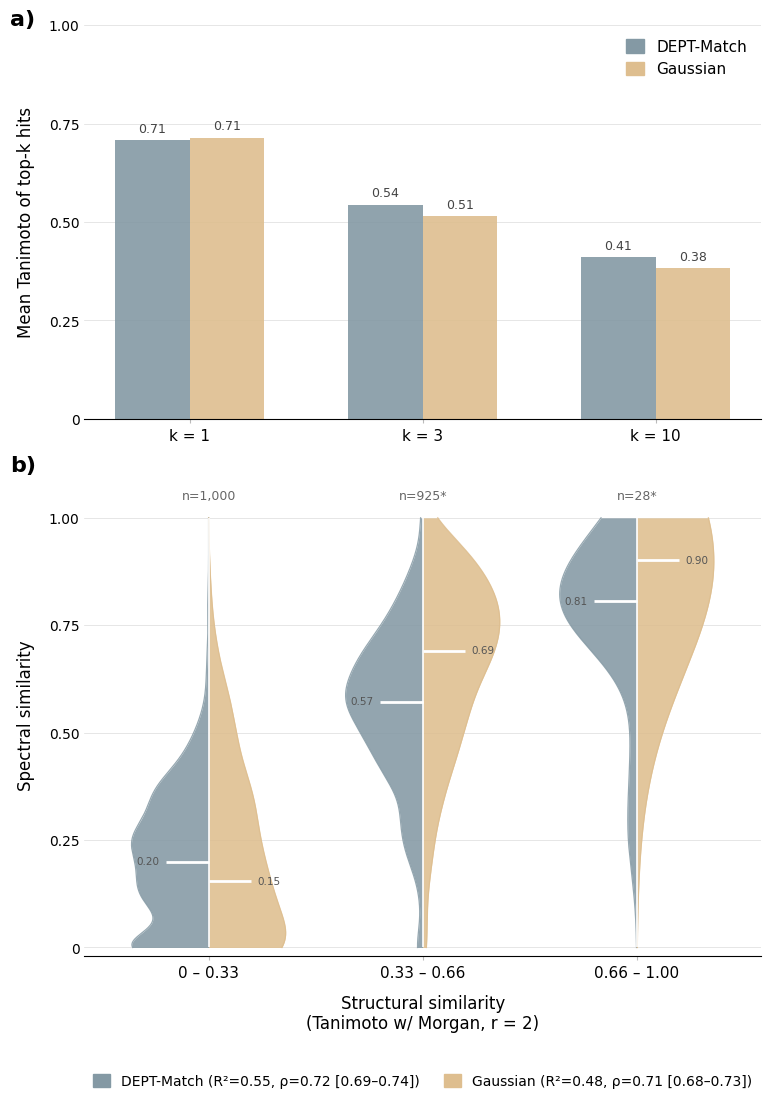

In [7]:
from scipy.stats import pearsonr, spearmanr

# Figure 3 — one figure, two stacked panels:
#   a) mean Tanimoto of the top-k retrieved hits (from the notebook-04 ranked lists)
#   b) structural vs. spectral similarity (split violins per Tanimoto bin)
VIOLIN_WIDTH = 0.36


def draw_half_violin(ax, data, x_pos, side, color, width=VIOLIN_WIDTH, alpha=0.88):
    """Draw one half of a split violin; returns the median of data."""
    data = np.asarray(data, dtype=float)
    data = data[np.isfinite(data)]
    if len(data) < 2:
        return None
    kde = gaussian_kde(data, bw_method="scott")
    y_grid = np.linspace(0.0, 1.0, 600)
    density = kde(y_grid)
    density = density / density.max() * width
    if side == "left":
        ax.fill_betweenx(y_grid, x_pos - density, x_pos, color=color, alpha=alpha, linewidth=0, zorder=2)
        ax.plot(x_pos - density, y_grid, color=color, linewidth=0.9, alpha=0.85, zorder=3)
    else:
        ax.fill_betweenx(y_grid, x_pos, x_pos + density, color=color, alpha=alpha, linewidth=0, zorder=2)
        ax.plot(x_pos + density, y_grid, color=color, linewidth=0.9, alpha=0.85, zorder=3)
    return float(np.median(data))


# Correlation statistics for the panel b legend
r_h, _ = pearsonr(results_df["tanimoto"], results_df["dept_match_cosine"])
r_g, _ = pearsonr(results_df["tanimoto"], results_df["gauss_cosine"])
rho_h, _ = spearmanr(results_df["tanimoto"], results_df["dept_match_cosine"])
rho_g, _ = spearmanr(results_df["tanimoto"], results_df["gauss_cosine"])
r2_hungarian = r_h**2
r2_gauss = r_g**2

# Bootstrap 95% CI for the overall Spearman rho: resample query-candidate pairs
# with replacement, recompute rho each iteration, take the 2.5/97.5 percentiles.
# The high-similarity bin holds only ~28 pairs, so the overall rho is driven by
# the low-similarity bin; the CI makes that estimation uncertainty explicit.
N_BOOTSTRAP = 1_000
_boot_rng = np.random.default_rng(RANDOM_SEED)
_tan = results_df["tanimoto"].to_numpy()
_dm = results_df["dept_match_cosine"].to_numpy()
_gg = results_df["gauss_cosine"].to_numpy()
_n_pairs = len(results_df)
_boot_h = np.empty(N_BOOTSTRAP)
_boot_g = np.empty(N_BOOTSTRAP)
for _b in range(N_BOOTSTRAP):
    _idx = _boot_rng.integers(0, _n_pairs, _n_pairs)
    _boot_h[_b] = spearmanr(_tan[_idx], _dm[_idx])[0]
    _boot_g[_b] = spearmanr(_tan[_idx], _gg[_idx])[0]
rho_h_ci = np.percentile(_boot_h, [2.5, 97.5])
rho_g_ci = np.percentile(_boot_g, [2.5, 97.5])
print(f"DEPT-Match: rho={rho_h:.2f}  95% CI [{rho_h_ci[0]:.2f}, {rho_h_ci[1]:.2f}]")
print(f"Gaussian  : rho={rho_g:.2f}  95% CI [{rho_g_ci[0]:.2f}, {rho_g_ci[1]:.2f}]")

method_color = {"DEPT-Match": COLOR_HUNGARIAN, "Gaussian": COLOR_GAUSS}

fig, (ax_bar, ax_vio) = plt.subplots(2, 1, figsize=(8, 11),
                                     gridspec_kw={"height_ratios": [0.9, 1.1]})

# ===== Panel a: mean Tanimoto of the top-k retrieved hits =====
K_REC = [1, 3, 10]
BAR_WIDTH = 0.32
x_r = np.arange(len(K_REC))
for method, offset in zip(["DEPT-Match", "Gaussian"], [-BAR_WIDTH / 2, BAR_WIDTH / 2]):
    vals = recovery_df[recovery_df["method"] == method].set_index("k").loc[K_REC, "mean_tanimoto"].values
    bars = ax_bar.bar(x_r + offset, vals, width=BAR_WIDTH, color=method_color[method], alpha=0.90, zorder=2)
    for bar, val in zip(bars, vals):
        ax_bar.text(bar.get_x() + bar.get_width() / 2, val + 0.012, f"{val:.2f}",
                    ha="center", va="bottom", fontsize=9, color="#444444")
ax_bar.set_xticks(x_r)
ax_bar.set_xticklabels([f"k = {k}" for k in K_REC], fontsize=11)
ax_bar.set_ylabel("Mean Tanimoto of top-k hits", fontsize=12, labelpad=10)
ax_bar.set_ylim(0, 1.0)
ax_bar.set_yticks([0.0, 0.25, 0.50, 0.75, 1.00])
ax_bar.set_yticklabels(["0", "0.25", "0.50", "0.75", "1.00"], fontsize=10)
ax_bar.yaxis.grid(True, linewidth=0.5, color="lightgray", alpha=0.8, zorder=0)
ax_bar.set_axisbelow(True)
ax_bar.spines[["top", "right", "left"]].set_visible(False)
ax_bar.tick_params(axis="y", length=0)
ax_bar.tick_params(axis="x", length=3, color="#bbbbbb")
ax_bar.legend(
    handles=[mpatches.Patch(color=method_color[m], label=m) for m in ["DEPT-Match", "Gaussian"]],
    frameon=False, loc="upper right", fontsize=11, handlelength=1.2, handleheight=1.0,
)
ax_bar.text(-0.11, 1.04, "a)", transform=ax_bar.transAxes, fontsize=16,
            fontweight="bold", va="top", ha="left")

# ===== Panel b: structural vs. spectral similarity (split violins per Tanimoto bin) =====
x_positions = {label: i for i, label in enumerate(BIN_LABELS)}
for label in BIN_LABELS:
    subset = results_df[results_df["tanimoto_bin"] == label]
    x = x_positions[label]
    n = len(subset)
    med_h = draw_half_violin(ax_vio, subset["dept_match_cosine"], x, "left", COLOR_HUNGARIAN)
    med_g = draw_half_violin(ax_vio, subset["gauss_cosine"], x, "right", COLOR_GAUSS)
    ax_vio.vlines(x, 0.0, 1.0, color="white", linewidth=1.2, zorder=4)
    tick_reach = VIOLIN_WIDTH * 0.55
    if med_h is not None:
        ax_vio.hlines(med_h, x - tick_reach, x, color="white", linewidth=2.0, zorder=5)
        ax_vio.text(x - tick_reach - 0.03, med_h, f"{med_h:.2f}", ha="right", va="center",
                    fontsize=7.5, color="#555555", zorder=6)
    if med_g is not None:
        ax_vio.hlines(med_g, x, x + tick_reach, color="white", linewidth=2.0, zorder=5)
        ax_vio.text(x + tick_reach + 0.03, med_g, f"{med_g:.2f}", ha="left", va="center",
                    fontsize=7.5, color="#555555", zorder=6)
    asterisk = "*" if n < N_PAIRS_PER_BIN else ""
    ax_vio.text(x, 1.035, f"n={int(n):,}{asterisk}", ha="center", va="bottom", fontsize=9, color="#666666", zorder=7)

ax_vio.set_xticks(range(len(BIN_LABELS)))
ax_vio.set_xticklabels(BIN_LABELS, fontsize=11)
ax_vio.set_xlabel("Structural similarity\n(Tanimoto w/ Morgan, r = 2)", fontsize=12, labelpad=10)
ax_vio.set_ylabel("Spectral similarity", fontsize=12, labelpad=10)
ax_vio.set_ylim(-0.02, 1.10)
ax_vio.set_xlim(-0.58, len(BIN_LABELS) - 0.42)
ax_vio.set_yticks([0.0, 0.25, 0.50, 0.75, 1.00])
ax_vio.set_yticklabels(["0", "0.25", "0.50", "0.75", "1.00"], fontsize=10)
ax_vio.yaxis.grid(True, linewidth=0.5, color="lightgray", alpha=0.8, zorder=0)
ax_vio.set_axisbelow(True)
ax_vio.spines[["top", "right", "left"]].set_visible(False)
ax_vio.tick_params(axis="y", length=0)
ax_vio.tick_params(axis="x", length=3, color="#bbbbbb")
# Legend below panel b (spanning both methods) so it no longer overlaps the violins.
ax_vio.legend(
    handles=[
        mpatches.Patch(
            color=COLOR_HUNGARIAN,
            label=f"DEPT-Match (R²={r2_hungarian:.2f}, ρ={rho_h:.2f} [{rho_h_ci[0]:.2f}–{rho_h_ci[1]:.2f}])",
        ),
        mpatches.Patch(
            color=COLOR_GAUSS,
            label=f"Gaussian (R²={r2_gauss:.2f}, ρ={rho_g:.2f} [{rho_g_ci[0]:.2f}–{rho_g_ci[1]:.2f}])",
        ),
    ],
    frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.22),
    ncol=2, fontsize=10, handlelength=1.2, handleheight=1.0, columnspacing=1.8,
)
ax_vio.text(-0.11, 1.04, "b)", transform=ax_vio.transAxes, fontsize=16,
            fontweight="bold", va="top", ha="left")

fig.tight_layout()
fig.savefig(f"{PROCESSED_DATA_DIR}/../figures/figure3.png", dpi=400, bbox_inches="tight")
plt.show()